In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor

In [6]:
data_cal = pd.read_csv("calories.csv")

In [7]:
data_cal.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [8]:
data_ez = pd.read_csv("exercise.csv")

In [9]:
data = pd.concat([data_ez, data_cal['Calories']], axis=1)
  

In [10]:
data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [12]:
data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [15]:
data['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_12944\581236967.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

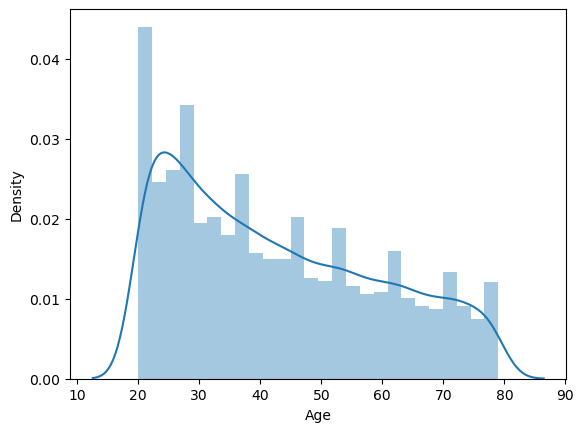

In [16]:
# Visualization
sns.distplot(data['Age'])

In [18]:
## Encoding Gender column

data.replace({'Gender': {'female':0,'male':1}}, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12944\2310287976.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Gender': {'female':0,'male':1}}, inplace=True)


In [19]:
data = data.drop(columns='User_ID', axis=1)

In [20]:
## Correlation in dataset

corr = data.corr()

<Axes: >

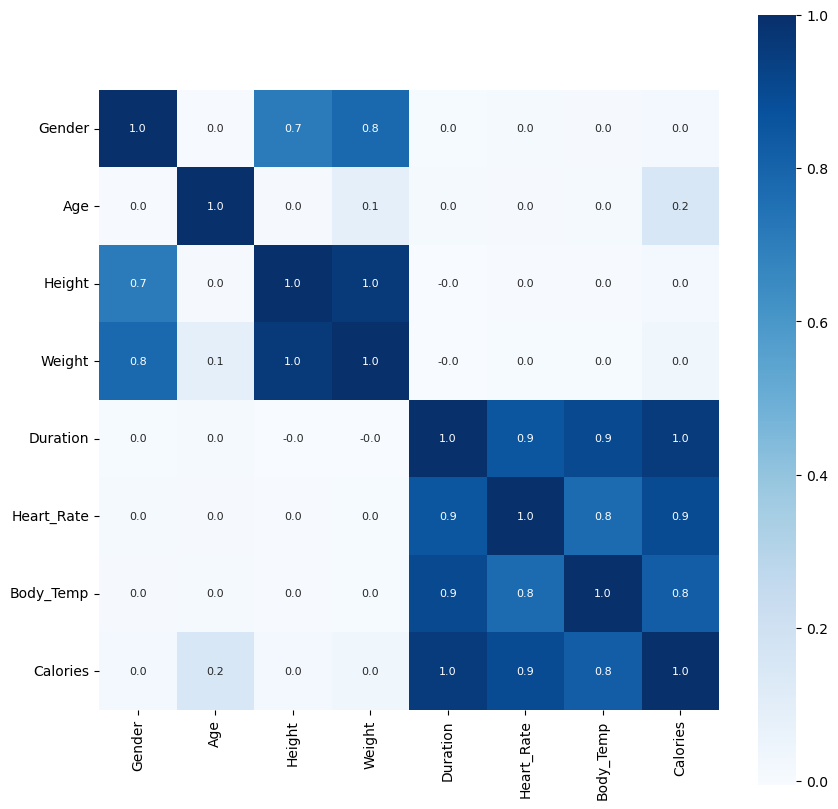

In [21]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size': 8}, cmap='Blues')

In [22]:
## Splitting features and target 

X = data.drop(columns= 'Calories', axis=1)
Y = data['Calories']

In [23]:
X.shape

(15000, 7)

In [24]:
Y.shape

(15000,)

In [25]:
X_train , X_test , Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [26]:
X_train.shape

(12000, 7)

In [27]:
Y_train.shape

(12000,)

In [28]:
model = XGBRegressor()

In [29]:
model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
# Model Prediction and evaluation

Train_pred = model.predict(X_train)

Train_score = metrics.r2_score(Y_train, Train_pred)

Train_score

0.9995777219604748

In [31]:
Test_pred = model.predict(X_test)

Test_score = metrics.r2_score(Y_test, Test_pred)

Test_score

0.9988678909361673

In [32]:
## Building a predictive model

input_data = [0,27,154.0,58.0,10.0,81.0,39.8]

input_data_as_np_array = np.asarray(input_data)

input_data_reshaped = input_data_as_np_array.reshape(1,-1)

Prediction = model.predict(input_data_reshaped)

print(f"MOdel has predicted the calories burnt are {Prediction}")

MOdel has predicted the calories burnt are [35.42778]
